In [17]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import holidays
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
raw_fc_data = pd.read_csv("electricity_price_forecast_assignment-quant_assignment-data/data/data_forecast.csv")
raw_act_data = pd.read_csv("electricity_price_forecast_assignment-quant_assignment-data/data/data_actual.csv")

raw_fc_data["valuetime"] = pd.to_datetime(raw_fc_data["valuetime"])
raw_fc_data["import"] =raw_fc_data["flow"].clip(lower=0)
raw_fc_data["export"] = (-raw_fc_data["flow"]).clip(lower=0)

raw_act_data["valuetime"] = pd.to_datetime(raw_act_data["valuetime"])
raw_act_data["import"] =raw_act_data["flow"].clip(lower=0)
raw_act_data["export"] = (-raw_act_data["flow"]).clip(lower=0)



Training data 60 days

Testing data 60-90 days

Validating data 90-12 days


SARIMA and SARIMAX because the data is small. Can use XGBoost when working with larger data

### SARIMA



sarima_v1.csv = (1,1,2) (0,1,1,24)

sarima_v2.csv = (1,1,2) (1,1,1,24)

sarima_v3.csv = (0,2,0) (1,0,1,24)

In [3]:
train_data = raw_act_data[0:60*24]
test_data = raw_act_data[60*24:90*24]
adf_result = adfuller(train_data['spot'])
print(f"ADF p-value: {adf_result[1]:.4f} (d={1 if adf_result[1] > 0.05 else 0})")

ADF p-value: 0.0014 (d=0)


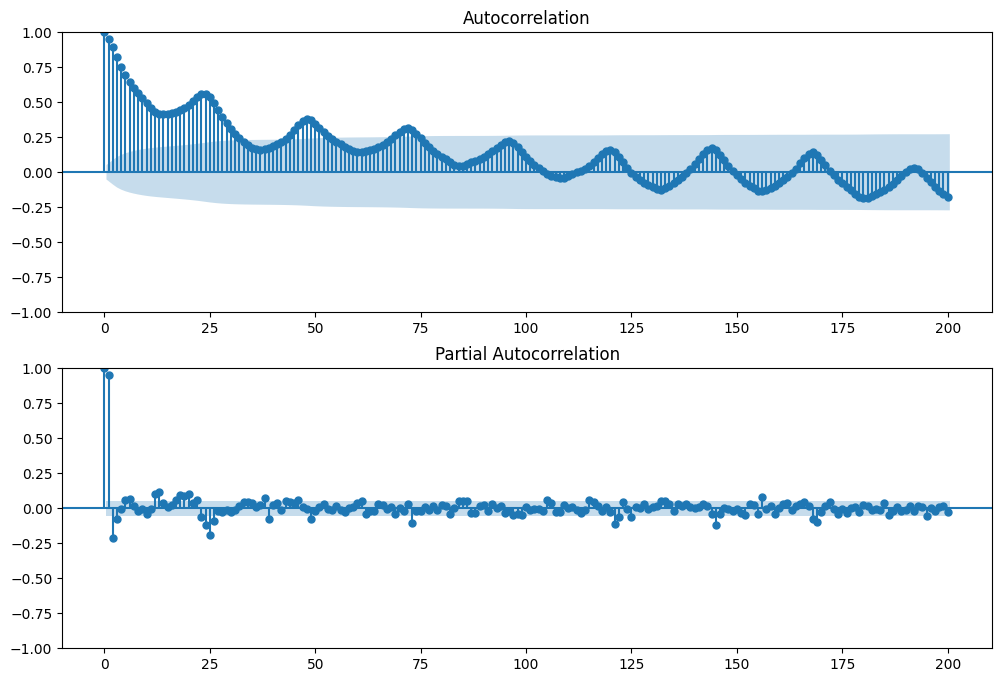

In [4]:
plt_data = train_data['spot']
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(plt_data, lags=200, ax=axes[0])
plot_pacf(plt_data, lags=200, ax=axes[1])
plt.show()

In [5]:
order = (1, 1, 2)
seasonal_order = (0, 1, 1, 24)

h = 24
train = train_data['spot'].copy()
test = test_data['spot'].copy()

all_forecasts = []
start_idx = 0

while start_idx + h <= len(test):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
            fitted = model.fit(disp=False)

        fc = fitted.get_forecast(steps=h)
        fc_mean = fc.predicted_mean
        fc_ci = fc.conf_int(alpha=0.05)

        actual = test.iloc[start_idx:start_idx + h]

        forecast_chunk = pd.DataFrame({
            "actual": actual.values,
            "forecast": fc_mean.values,
            "lower_95": fc_ci.iloc[:, 0].values,
            "upper_95": fc_ci.iloc[:, 1].values
                                      }, index=actual.index)

        all_forecasts.append(forecast_chunk)

        train = pd.concat([train, actual])
        start_idx += h

    except Exception as e:
        print(f"FAILED at start_idx={start_idx} | order={order}, seasonal_order={seasonal_order} | Error: {e}")
        start_idx += h
    
    print(f"Days Completed: {start_idx/24}")
    

forecast_df = pd.concat(all_forecasts)

Days Completed: 1.0
Days Completed: 2.0
Days Completed: 3.0
Days Completed: 4.0
Days Completed: 5.0
Days Completed: 6.0
Days Completed: 7.0
Days Completed: 8.0
Days Completed: 9.0
Days Completed: 10.0
Days Completed: 11.0
Days Completed: 12.0
Days Completed: 13.0
Days Completed: 14.0
Days Completed: 15.0
Days Completed: 16.0
Days Completed: 17.0
Days Completed: 18.0
Days Completed: 19.0
Days Completed: 20.0
Days Completed: 21.0
Days Completed: 22.0
Days Completed: 23.0
Days Completed: 24.0
Days Completed: 25.0
Days Completed: 26.0
Days Completed: 27.0
Days Completed: 28.0
Days Completed: 29.0
Days Completed: 30.0


In [8]:
mae  = mean_absolute_error(forecast_df["actual"], forecast_df["forecast"])
rmse = np.sqrt(mean_squared_error(forecast_df["actual"], forecast_df["forecast"]))
mape = ((forecast_df["actual"] - forecast_df["forecast"]) / forecast_df["actual"]).abs().mean() * 100

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE:  9.94
RMSE: 13.43
MAPE: 194.11%


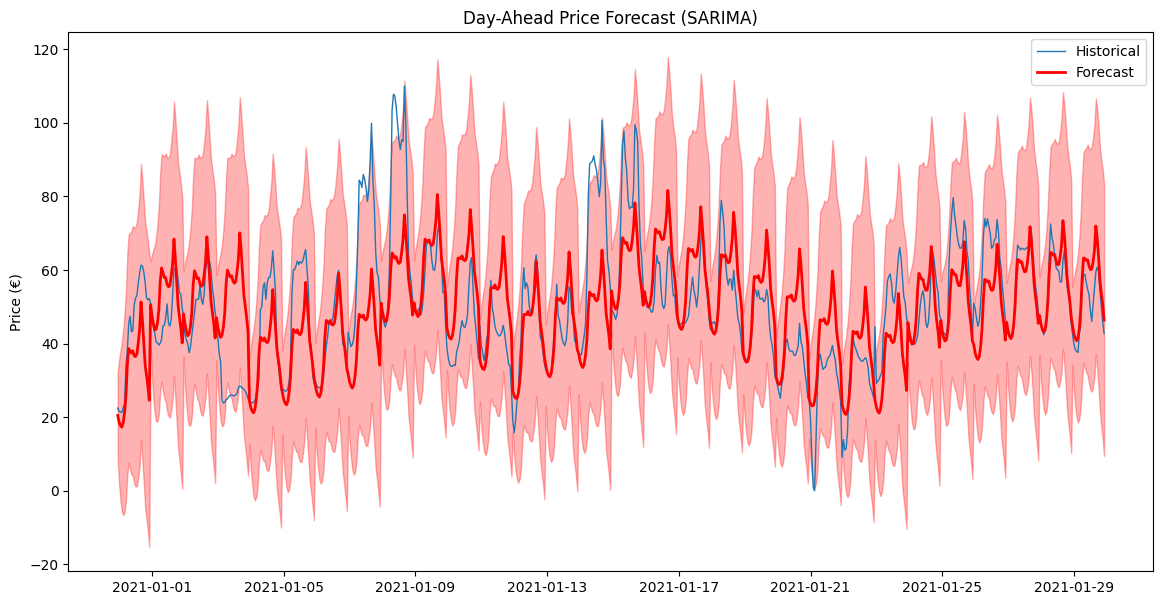

In [10]:
forecast_df.index = test_data["valuetime"]
# Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(forecast_df["actual"].index, forecast_df["actual"], label='Historical', linewidth=1)  # Last week
ax.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='red', linewidth=2)
ax.fill_between(forecast_df.index, forecast_df['lower_95'], forecast_df['upper_95'], color='red', alpha=0.3)
ax.set_ylabel('Price (€)')
ax.legend()
ax.set_title('Day-Ahead Price Forecast (SARIMA)')
plt.savefig('sarima_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

### SARIMAX

Next step:

- Can introduce wind, solar, load, forecasting errors extreme values and create price scenarios

In [39]:
dk_holidays = holidays.Denmark(years=range(2020, 2022))


raw_fc_data["is_weekend"] = (raw_fc_data["valuetime"].dt.dayofweek >= 5).astype(int)
raw_fc_data["is_holiday"] = raw_fc_data["valuetime"].isin(dk_holidays).astype(int)
raw_fc_data["hour_sin"] = np.sin(2 * np.pi * raw_fc_data["valuetime"].dt.hour / 24)
raw_fc_data["hour_cos"] = np.cos(2 * np.pi * raw_fc_data["valuetime"].dt.hour / 24)
raw_fc_data["dayofweek_sin"] = np.sin(2 * np.pi * raw_fc_data["valuetime"].dt.dayofweek / 7)
raw_fc_data["dayofweek_cos"] = np.cos(2 * np.pi * raw_fc_data["valuetime"].dt.dayofweek / 7)

raw_fc_data["wind_pen"] = ((raw_fc_data["wind"]/raw_fc_data["load"])).fillna(0)
raw_fc_data["solar_pen"] = (raw_fc_data["solar"]/raw_fc_data["load"]).fillna(0)
raw_fc_data["import_pen"] = ((raw_fc_data["import"])/raw_fc_data["load"]).fillna(0)

raw_act_data["wind_fc_error"] = (1 - (raw_fc_data["wind"]/raw_act_data["wind"])).fillna(0)
raw_act_data["solar_fc_error"] = ( (raw_act_data["solar"]- raw_fc_data["solar"])/raw_act_data["solar"].replace(0,1)).fillna(0)
raw_act_data["load_fc_error"] = (1 - (raw_fc_data["load"]/raw_act_data["load"])).fillna(0)

raw_act_data["wind_pen"] = ((raw_fc_data["wind"]/raw_act_data["load"])).fillna(0)
raw_act_data["solar_pen"] = (raw_act_data["solar"]/raw_act_data["load"]).fillna(0)
raw_act_data["import_pen"] = ((raw_act_data["import"])/raw_act_data["load"]).fillna(0)

raw_act_data["is_weekend"] = (raw_act_data["valuetime"].dt.dayofweek >= 5).astype(int) 
raw_act_data["is_holiday"] = raw_act_data["valuetime"].isin(dk_holidays).astype(int)
raw_act_data["hour_sin"] = np.sin(2 * np.pi * raw_act_data["valuetime"].dt.hour / 24)
raw_act_data["hour_cos"] = np.cos(2 * np.pi * raw_act_data["valuetime"].dt.hour / 24)
raw_act_data["dayofweek_sin"] = np.sin(2 * np.pi * raw_act_data["valuetime"].dt.dayofweek / 7)
raw_act_data["dayofweek_cos"] = np.cos(2 * np.pi * raw_act_data["valuetime"].dt.dayofweek / 7)

C:\Users\Bruger\AppData\Local\Temp\ipykernel_20884\3647123097.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  raw_fc_data["is_holiday"] = raw_fc_data["valuetime"].isin(dk_holidays).astype(int)
C:\Users\Bruger\AppData\Local\Temp\ipykernel_20884\3647123097.py:24: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  raw_act_data["is_holiday"] = raw_act_data["valuetime"].isin(dk_holidays).astype(int)


In [40]:
train_data = raw_act_data[0:60*24]
test_data_act = raw_act_data[60*24:90*24]
test_data_fc = raw_fc_data[60*24:90*24]

order = (1, 1, 2)
seasonal_order = (0, 1, 1, 24)
feature_cols =["wind", "solar", "load", "import", "export", "wind_pen", "solar_pen", "import_pen"]

h = 24
train = train_data.copy()
test = test_data_fc.copy()


model = SARIMAX(
    endog=train['spot'],
    exog=train[feature_cols],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=True, method_kwargs={'maxiter': 500})

c:\Users\Bruger\miniconda3\envs\test_env\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: method_kwargs. After release 0.14, this will raise.
  warnings.warn(
c:\Users\Bruger\miniconda3\envs\test_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                 spot   No. Observations:                 1440
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 24)   Log Likelihood               -4489.876
Date:                              Thu, 21 May 2026   AIC                           9005.751
Time:                                      19:32:50   BIC                           9073.814
Sample:                                           0   HQIC                          9031.206
                                             - 1440                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
wind          -0.0017      0.001     -1.455      0.146      -0.004       0.001
solar         -0.1243      0.101     -1.232      0.218      -0.322       0.073
load           0.0049      0.003      1.896      0.058      -0.000       0.010
import         0.0112      0.002      5.507      0.000       0.007       0.015
export        -0.0017      0.002     -1.138      0.255      -0.005       0.001
wind_pen      -8.7645      3.849     -2.277      0.023     -16.309      -1.220
solar_pen    279.4993    267.436      1.045      0.296    -244.666     803.665
import_pen   -17.1379      4.880     -3.512      0.000     -26.702      -7.573
ar.L1          0.4303      4.144      0.104      0.917      -7.692       8.552
ma.L1         -0.3891      4.145     -0.094      0.925      -8.514       7.736
ma.L2         -0.0180      0.170     -0.106      0.916      -0.351       0.315
ma.S.L24      -1.0286      0.015    -66.969      0.000      -1.059      -0.999
sigma2        34.8667      1.137     30.661      0.000      32.638      37.096
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):              2474.50
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.34
Prob(H) (two-sided):                  0.67   Kurtosis:                         9.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
train_data = raw_act_data[0:60*24]
correlations = train_data.corrwith(train_data['spot']).sort_values(ascending=False)
print(correlations.drop('spot'))

load              0.440309
valuetime         0.166731
dayofweek_sin     0.133917
wind_fc_error     0.107801
solar             0.017164
load_fc_error     0.015701
solar_pen         0.011381
is_holiday       -0.013240
flow             -0.016394
import           -0.045401
export           -0.055247
hour_sin         -0.125146
import_pen       -0.132535
dayofweek_cos    -0.145212
solar_fc_error   -0.145794
is_weekend       -0.156980
hour_cos         -0.315954
wind             -0.634301
wind_pen         -0.806466
dtype: float64


In [44]:
fc = fitted.get_forecast(steps=h, exog=test[feature_cols].iloc[:h])
fc_mean = fc.predicted_mean

forecast_df = pd.DataFrame({"actual": test_data_act["spot"].iloc[:h].values, "forecast": fc_mean.values})

mae  = mean_absolute_error(forecast_df["actual"], forecast_df["forecast"])
rmse = np.sqrt(mean_squared_error(forecast_df["actual"], forecast_df["forecast"]))
mape = ((forecast_df["actual"] - forecast_df["forecast"]) / forecast_df["actual"]).abs().mean() * 100

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE:  17.11
RMSE: 18.70
MAPE: 38.42%
